In [1]:
#W1 D4 - multiple tasks 

# - recreating the data collection flow 
import os
import pandas as pd
data_folder = '../data/'
path = os.path.join(data_folder)

df = pd.DataFrame()
df2 = pd.DataFrame()
for file in os.listdir(path):
    if 'price_history' in file:
        df2 = pd.read_csv(data_folder + file)
        df = pd.concat([df, df2])

meta_path = '../data/all_products_meta.csv'
meta = pd.read_csv(meta_path)
merged_df = df.merge(meta)

#Converting listedSince to a proper datetime + adding days_since_launch in days 
KEEPA_EPOCH = pd.Timestamp('2011-01-01')
merged_df['listedSince'] = pd.to_datetime(KEEPA_EPOCH + pd.to_timedelta(merged_df['listedSince'], 'minutes'))
merged_df['datetime'] = pd.to_datetime(merged_df['datetime'])
merged_df['days_since_launch'] = (merged_df['datetime'] - merged_df['listedSince']).dt.days

#doing checks an dprints
print(merged_df['days_since_launch'].min(), merged_df['days_since_launch'].max())
count_below_0 =  merged_df[merged_df['days_since_launch'] < 0]

#filtering out days with days_since_launch below 0
merged_df = merged_df[merged_df['days_since_launch'] > 0]

#Identifying and filtering price outliesr (3x median)
merged_df = merged_df[merged_df['NEW'].notna()]
merged_df['NEW'] = merged_df.groupby('asin')['NEW'].ffill()
merged_df['median'] = merged_df.groupby('asin')['NEW'].transform('median')
merged_df['is_outlier'] = merged_df['NEW'] > merged_df['median'] * 3
merged_df.head

#checking, filtering them out
print(merged_df.groupby('asin')['is_outlier'].value_counts())
print(merged_df.shape)
merged_df = merged_df[merged_df['is_outlier'] == False]
print(merged_df.shape)


-51 2326
asin        is_outlier
B07ZPKN6YR  False         2935
            True           324
B08L34JQ9C  False         3978
            True            30
B08MV7HWFK  False         3062
            True           321
B08PP5MSVB  False         6672
            True             6
B08VLMQ3KS  False         4821
            True            26
B09LNW3CY2  False         6483
B09SYSMCX6  False         1660
B09VH9BKHS  False         2089
B0BL8HPF13  False         2403
            True             2
B0BN72FYFG  False         5683
B0C5S83319  False         1633
B0CMPMY9ZZ  False         3492
B0CVYKL34H  False         1607
B0D364RMMP  False         1390
B0DHJDPYYR  False         1616
B0DVHV7X53  False          848
B0FFTV1LXZ  False          252
B0FG1THCD7  False          167
B0FRKS39NK  False           85
Name: count, dtype: int64
(51585, 31)
(50876, 31)


In [2]:
#W1 D4 - visualization - today we're looking at multiple phones - Apple iPhones only
import plotly.express as px

pd.set_option('display.max_columns', None)
merged_df.head
iphone_df = merged_df[merged_df['brand'] == 'Apple']
iphone_df.head

chart = px.line(iphone_df, 'datetime', 'NEW', color='model', title='iPhone Price Evolution') #this still feels unintuitive, but I will practice and learn it well
chart.show()

We can clearly observe downtrend, but also some weird outliers - I'm wondering if for iPhone 16 there really were intended price spikes in Dec 24' or it's simply some kind of an error


In [ ]:
#W1 D5 

#T1 - Recreating the whole clean pipeline from scratch in one cell

import os
import pandas as pd

df = pd.DataFrame()
df2 = pd.DataFrame()

data_path = os.path.join('../data/')
meta_path = os.path.join('../data/all_products_meta.csv')

for file in os.listdir(data_path):
    if 'price_history' in file:
        df2 = pd.read_csv(data_path + file)
        df = pd.concat([df, df2])
#data loaded


#merging with meta + converting keepa timestamps - this is a step I've figured out by looking at the docs
#as keepa API returns some date outputs (trackingSince/listedSince) in the number of minutes from 2011-01-01 (KEEPA_EPOCH below)
meta = pd.read_csv(meta_path)
df = df.merge(meta, on = 'asin')
KEEPA_EPOCH = pd.Timestamp('2011-01-01')
df['listedSince'] = KEEPA_EPOCH + pd.to_timedelta(df['listedSince'], 'minutes')
df['trackingSince'] = KEEPA_EPOCH + pd.to_timedelta(df['trackingSince'], 'minutes')
print(df.shape)

#adding days since launch column + filtering out rows with days since launch below 0
df['datetime'] = pd.to_datetime(df['datetime'])
df['days_since_launch'] = (df['datetime'] - df['listedSince']).dt.days
df = df[df['days_since_launch'] > 0]
print(df.shape)

#filtering out the outliers (here set at 3x median for each asin)
df['median'] = df.groupby('asin')['NEW'].transform('median')
df['is_outlier'] = df['NEW'] > df['median'] * 3
df = df[~df['is_outlier']]
print(df.shape)

#resampling NEW prices to weekly minimums for every asin
df = df.set_index('datetime', drop = True)
df = df.groupby('asin')['NEW'].resample('W').min().reset_index()
df['NEW'] = df.groupby('asin')['NEW'].ffill(0)
print(df.head)



(170608, 28)
(170600, 29)
(169891, 31)
<bound method NDFrame.head of             asin   datetime     NEW
0     B07ZPKN6YR 2019-11-10     NaN
1     B07ZPKN6YR 2019-11-17     NaN
2     B07ZPKN6YR 2019-11-24     NaN
3     B07ZPKN6YR 2019-12-01     NaN
4     B07ZPKN6YR 2019-12-08     NaN
...          ...        ...     ...
3061  B0FRKS39NK 2026-02-15  827.99
3062  B0FRKS39NK 2026-02-22  761.02
3063  B0FRKS39NK 2026-03-01  730.14
3064  B0FRKS39NK 2026-03-08  782.99
3065  B0FRKS39NK 2026-03-15  771.82

[3066 rows x 3 columns]>


In [44]:
'''Task 2 [3 pts]**
Re-plot the multi-iPhone chart using the cleaned, resampled DataFrame.
- Filter to Apple only
- px.line, color by model, title "iPhone Weekly NEW Price — All Models (Cleaned)"
- Add a markdown cell below with 3–4 analytical observations (price levels, decay rate, anomalies)'''


import plotly.express as px
#But now there's an issue, since we only had 3 columns in the final version of the resampled df, so we have to merge again on asins
meta_df = df.merge(meta, on = 'asin')
apple_df = meta_df[meta_df['brand'] == 'Apple']
print(apple_df.head())

multi_chart = px.line(apple_df, 'datetime', 'NEW', color = 'model', title = 'iPhone weekly new price - all models (cleaned)')
multi_chart.show()

         asin   datetime  NEW  \
0  B07ZPKN6YR 2019-11-10  NaN   
1  B07ZPKN6YR 2019-11-17  NaN   
2  B07ZPKN6YR 2019-11-24  NaN   
3  B07ZPKN6YR 2019-12-01  NaN   
4  B07ZPKN6YR 2019-12-08  NaN   

                                               title  brand      model  \
0  Apple iPhone 11, 64GB, Black - Unlocked (Renewed)  Apple  iPhone 11   
1  Apple iPhone 11, 64GB, Black - Unlocked (Renewed)  Apple  iPhone 11   
2  Apple iPhone 11, 64GB, Black - Unlocked (Renewed)  Apple  iPhone 11   
3  Apple iPhone 11, 64GB, Black - Unlocked (Renewed)  Apple  iPhone 11   
4  Apple iPhone 11, 64GB, Black - Unlocked (Renewed)  Apple  iPhone 11   

     manufacturer productGroup      binding  color  size  monthlySold  \
0  Apple Computer     Wireless  Electronics  Black  64GB         2000   
1  Apple Computer     Wireless  Electronics  Black  64GB         2000   
2  Apple Computer     Wireless  Electronics  Black  64GB         2000   
3  Apple Computer     Wireless  Electronics  Black  64GB        

The prices seem to be in a steady downtrend - this chart would look much better with relative values (mom % changes) though, and I'll certainly create one.
There are some holes in data, which have to be handled somehow - ffill maybe or bfill. 

There are also single outliers here and there, but there are less than 3 such cases, so nothing to worry too much about - perhaps we could do a simple filter for prices below 50, or something like that - iPhones don't go that low.

There are also certain situations during which the price stabilizes or increases (by just a bit)


asin        brand    count  title                                                                                                                                                                                       model          manufacturer         productGroup  binding         color           size   monthlySold  listedSince  trackingSince  rootCategory  parentAsin
B07ZPKN6YR  Apple    332    Apple iPhone 11, 64GB, Black - Unlocked (Renewed)                                                                                                                                           iPhone 11      Apple Computer       Wireless      Electronics     Black           64GB   2000         4640100      4656740        2335752011    B0GR1S2JM2    1
B08L34JQ9C  Samsung  283    Samsung Galaxy S20 FE 5G, 128GB, Cloud Navy - Unlocked (Renewed)                                                                                                                            Galaxy S20 FE  Samsung Electronics  W

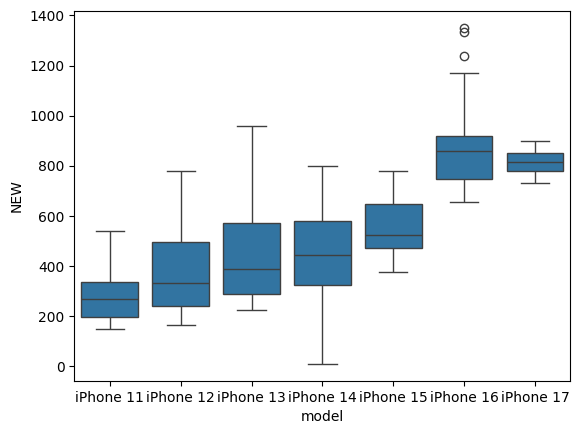

In [96]:
'''## Part 2 — Seaborn box plot [5 pts]

**Task 3 [2 pts]**
Import seaborn. Using the cleaned resampled Apple DataFrame:
- Plot a box plot: x=model, y=NEW
- Title: "iPhone NEW Price Distribution by Model"
- What does the box plot tell you that the line chart doesn't?'''


import seaborn as sns
box_plot = sns.boxplot(
    apple_df,
    x = 'model',
    y = 'NEW'
)

'''T5
From the full resampled DataFrame (all ASINs), check how many weekly price points each ASIN has.
Pick the Samsung and Google ASIN with the most data points each.
Print your choice and the row counts.'''



counts = df['asin'].value_counts().reset_index()
counts = counts.merge(meta, on = 'asin')
top_counts = counts.groupby(['asin', 'brand']).value_counts()
print(top_counts)


'''T6
Filter the resampled DataFrame to: all Apple iPhones + the two chosen ASINs.
Add a `brand` column (merge from meta if not already present).
Plot px.line, color by brand, title "Weekly NEW Price by Brand".
One sentence: what does the cross-brand comparison show?
'''

df = df.merge(meta, on = 'asin')
df.head()
filtered_df = df[(df['brand'] == 'Apple') | (df['asin'] == 'B08L34JQ9C') | (df['asin'] == 'B08VLMQ3KS')]
filtered_df.head()

import plotly.express as px

chart = px.line(filtered_df, 'datetime', 'NEW', color = 'brand', title = 'Weekly new price by brand')
chart.show()